# 관광특구 순성장률 ↔ 상권확장 비율 분석
- 목적: 관광특구 상권이 코로나 전후로 어떻게 변화했는지 확인
- 데이터: 서울시 상권변화지표 (2019Q1 ~ 2024Q4)
- 분석: 상권확장 비율 추이, 전체 상권 대비 비교

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [5]:
#상권변화지표 데이터 불러오기
df = pd.read_csv(
    "../data/08_상권변화지표/서울시 상권분석서비스(상권변화지표-상권).csv",
    encoding="cp949"  # 한글 인코딩
)


# 분석 기간 필터링: 2019~2024만 사용 (2025 데이터 제외)
df = df[df['기준_년분기_코드'] < 20250]

# 연도 컬럼 추가: 기준_년분기_코드 앞 4자리 추출
# 예) 20191 → 2019
df['연도'] = df['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 관광특구만 필터링
관광 = df[df['상권_구분_코드_명'] == '관광특구'].copy()

# 결과 확인
print("관광특구 상권 목록:")
print(관광['상권_코드_명'].unique())
print(f"\n총 {관광['상권_코드_명'].nunique()}개 관광특구 상권")

관광특구 상권 목록:
<StringArray>
[           '강남 마이스 관광특구',                '잠실 관광특구',             '종로?청계 관광특구',
           '동대문패션타운 관광특구', '명동 남대문 북창동 다동 무교동 관광특구',               '이태원 관광특구']
Length: 6, dtype: str

총 6개 관광특구 상권


## 관광특구 전체 평균 상권확장 비율 추이
- 관광특구 6개를 하나로 묶어서 연도별 추이 확인
- 전체 상권 유형(골목/발달/전통시장)과 비교

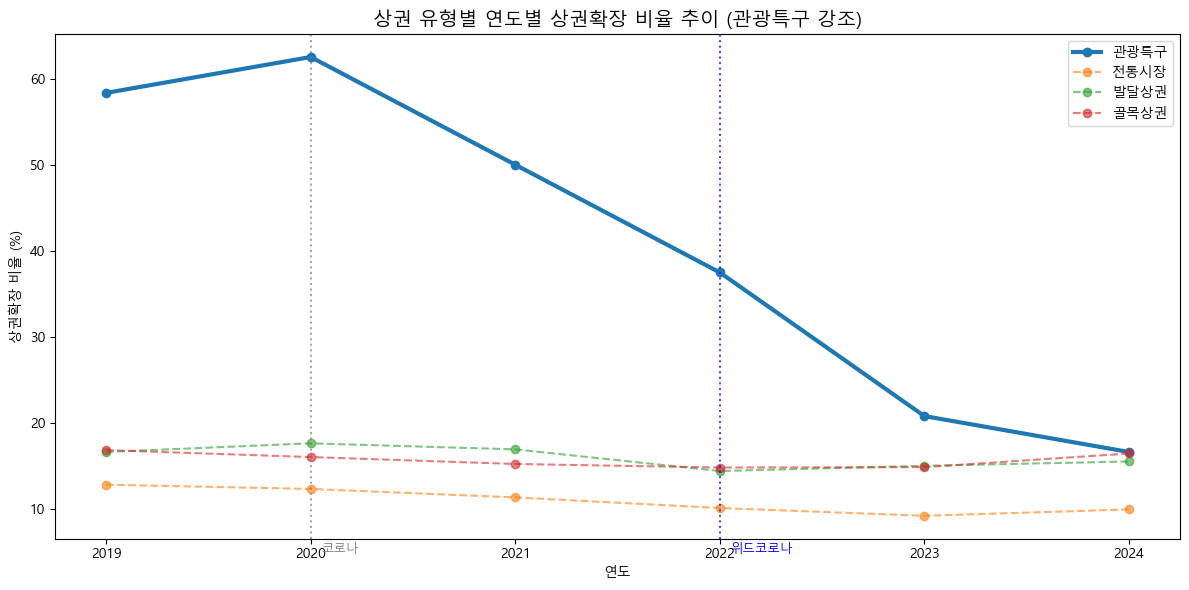

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

# 상권 유형별 연도별 상권확장 비율 계산
for 유형 in df['상권_구분_코드_명'].unique():
    df_유형 = df[df['상권_구분_코드_명'] == 유형]
    전체 = df_유형.groupby('연도').size()
    확장 = df_유형[df_유형['상권_변화_지표_명'] == '상권확장'].groupby('연도').size()
    비율 = (확장 / 전체 * 100).fillna(0)
    
    # 관광특구만 굵게 강조
    if 유형 == '관광특구':
        ax.plot(비율.index, 비율.values, marker='o', linewidth=3, label=유형)
    else:
        ax.plot(비율.index, 비율.values, marker='o', linewidth=1.5, 
                linestyle='--', alpha=0.6, label=유형)

# 코로나 시점 표시
ax.axvline(x=2020, color='gray', linestyle=':', alpha=0.7)
ax.axvline(x=2022, color='blue', linestyle=':', alpha=0.7)
ax.text(2020.05, 5, '코로나', fontsize=9, color='gray')
ax.text(2022.05, 5, '위드코로나', fontsize=9, color='blue')

ax.set_title('상권 유형별 연도별 상권확장 비율 추이 (관광특구 강조)', fontsize=14)
ax.set_xlabel('연도')
ax.set_ylabel('상권확장 비율 (%)')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
import glob

# 경로 확인
파일목록 = sorted(glob.glob("../data/*.csv"))

print("찾은 파일:")
for f in 파일목록:
    print(f)

찾은 파일:
../data\서울시 상권분석서비스(점포-상권)_2024년.csv
../data\서울시_상권분석서비스(점포-상권)_2019년.csv
../data\서울시_상권분석서비스(점포-상권)_2020년.csv
../data\서울시_상권분석서비스(점포-상권)_2021년.csv
../data\서울시_상권분석서비스(점포-상권)_2022년.csv
../data\서울시_상권분석서비스(점포-상권)_2023년.csv


## 점포 데이터 합치기 및 순성장률 계산
- 6개 연도 파일을 하나로 합치기
- 순성장률 = 개업률 - 폐업률
- 관광특구만 필터링

In [9]:
# 6개 파일 하나로 합치기
df_list = []
for 파일 in 파일목록:
    df_temp = pd.read_csv(파일, encoding='cp949')
    df_list.append(df_temp)

# 전체 합치기
df_점포 = pd.concat(df_list, ignore_index=True)

# 연도 컬럼 추가
df_점포['연도'] = df_점포['기준_년분기_코드'].astype(str).str[:4].astype(int)

# 2024까지만 사용
df_점포 = df_점포[df_점포['연도'] <= 2024]

print(f"전체 행 수: {len(df_점포):,}")
print(f"연도 범위: {df_점포['연도'].min()} ~ {df_점포['연도'].max()}")
print(f"상권 구분: {df_점포['상권_구분_코드_명'].unique()}")

전체 행 수: 1,831,925
연도 범위: 2019 ~ 2024
상권 구분: <StringArray>
['골목상권', '발달상권', '전통시장', '관광특구']
Length: 4, dtype: str


## 관광특구 순성장률 계산 (연도별)
- 관광특구만 필터링
- 순성장률 = 개업률 - 폐업률

In [10]:
# 관광특구만 필터링
df_관광_점포 = df_점포[df_점포['상권_구분_코드_명'] == '관광특구'].copy()

# 연도별 개업/폐업/점포수 합계
연도별 = df_관광_점포.groupby('연도').agg(
    총개업수=('개업_점포_수', 'sum'),
    총폐업수=('폐업_점포_수', 'sum'),
    총점포수=('점포_수', 'sum')
).reset_index()

# 개업률, 폐업률, 순성장률 계산
연도별['개업률'] = (연도별['총개업수'] / 연도별['총점포수'] * 100).round(2)
연도별['폐업률'] = (연도별['총폐업수'] / 연도별['총점포수'] * 100).round(2)
연도별['순성장률'] = (연도별['개업률'] - 연도별['폐업률']).round(2)

print(연도별[['연도', '개업률', '폐업률', '순성장률']])

     연도   개업률   폐업률  순성장률
0  2019  3.53  2.47  1.06
1  2020  2.61  2.72 -0.11
2  2021  2.21  2.51 -0.30
3  2022  2.26  1.95  0.31
4  2023  2.28  2.26  0.02
5  2024  1.24  2.32 -1.08


## 관광특구 순성장률 vs 상권확장 비율 비교
- 순성장률(소희님): 점포 증감 관점
- 상권확장 비율(나경님): 상권 생존력 관점
- 두 지표가 같은 방향으로 움직이는지 확인

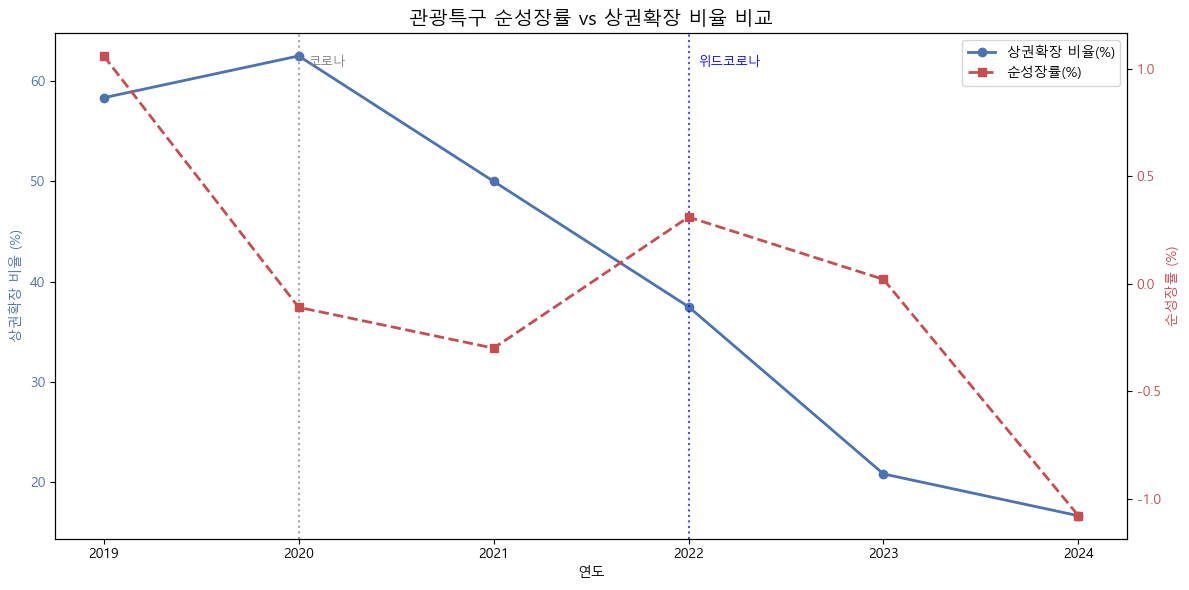

In [12]:
# 나경 데이터에서 관광특구 상권확장 비율 계산 (연도별)
전체 = 관광.groupby('연도').size()
확장 = 관광[관광['상권_변화_지표_명'] == '상권확장'].groupby('연도').size()
확장_비율 = (확장 / 전체 * 100).fillna(0).reset_index()
확장_비율.columns = ['연도', '상권확장_비율']

# 두 데이터 합치기
비교_df = pd.merge(확장_비율, 연도별[['연도', '순성장률']], on='연도')

# 그래프 그리기 (축 2개)
fig, ax1 = plt.subplots(figsize=(12, 6))

# 왼쪽 축: 상권확장 비율
ax1.plot(비교_df['연도'], 비교_df['상권확장_비율'], 
         marker='o', color='#4C72B0', linewidth=2, label='상권확장 비율(%)')
ax1.set_ylabel('상권확장 비율 (%)', color='#4C72B0')
ax1.tick_params(axis='y', labelcolor='#4C72B0')

# 오른쪽 축: 순성장률
ax2 = ax1.twinx()
ax2.plot(비교_df['연도'], 비교_df['순성장률'], 
         marker='s', color='#C44E52', linewidth=2, linestyle='--', label='순성장률(%)')
ax2.set_ylabel('순성장률 (%)', color='#C44E52')
ax2.tick_params(axis='y', labelcolor='#C44E52')

# 코로나 시점 표시
ax1.axvline(x=2020, color='gray', linestyle=':', alpha=0.7)
ax1.axvline(x=2022, color='blue', linestyle=':', alpha=0.7)
ax1.text(2020.05, ax1.get_ylim()[1]*0.95, '코로나', fontsize=9, color='gray')
ax1.text(2022.05, ax1.get_ylim()[1]*0.95, '위드코로나', fontsize=9, color='blue')

# 범례
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('관광특구 순성장률 vs 상권확장 비율 비교', fontsize=14)
ax1.set_xlabel('연도')
plt.tight_layout()
plt.show()

In [13]:
# 연도별 상권확장 비율 확인 (관광특구 전체 평균)
전체 = 관광.groupby('연도').size()
확장 = 관광[관광['상권_변화_지표_명'] == '상권확장'].groupby('연도').size()
비율 = (확장 / 전체 * 100).fillna(0)

print("연도별 전체 분기 수:")
print(전체)
print("\n연도별 상권확장 분기 수:")
print(확장)
print("\n연도별 상권확장 비율:")
print(비율.round(1))

연도별 전체 분기 수:
연도
2019    24
2020    24
2021    24
2022    24
2023    24
2024    24
dtype: int64

연도별 상권확장 분기 수:
연도
2019    14
2020    15
2021    12
2022     9
2023     5
2024     4
dtype: int64

연도별 상권확장 비율:
연도
2019    58.3
2020    62.5
2021    50.0
2022    37.5
2023    20.8
2024    16.7
dtype: float64
